# 05 — Compare runs

Every finished run in one table, with the noise floor applied to every comparison.

**The rule this notebook enforces.** Two byte-identical configurations differing
only in the random seed were measured 0.067 macro AUC apart on this task. Anything
closer than that is reported as no difference detected, which is a finding and not
a failure. A ranking inside the noise floor is a ranking of nothing.

It reads `results/` and writes one CSV. It trains nothing.

## Configuration

In [1]:
from pathlib import Path

REPO_ROOT = Path.cwd().parent

# Where notebook 03 writes runs. One test_NNN_* folder each, with results.json.
CLASSIFIER_RESULTS = REPO_ROOT / "results" / "classifier"

# The dissertation record: the thirteen reported experiments, one folder per
# test, with the summary CSV the thesis tables are built from. A campaign you
# collect yourself with notebook 07 lands in results/federated/ instead; point
# these two lines there to compare your own runs.
THESIS_RESULTS = REPO_ROOT / "results" / "thesis"
THESIS_SUMMARY = THESIS_RESULTS / "all_experiments.csv"

# OUTPUT. Overwritten every time this notebook runs.
OUT_CSV = CLASSIFIER_RESULTS / "all_experiments.csv"

# The margin below which a difference is not a result.
NOISE_FLOOR = 0.067

print(f"classifier runs  {CLASSIFIER_RESULTS}")
print(f"thesis record    {THESIS_RESULTS}")
print(f"writes           {OUT_CSV}")

classifier runs  /Users/daniel/Developer/tese/federated-breast-mri-subtyping/results/classifier
federated runs   /Users/daniel/Developer/tese/federated-breast-mri-subtyping/results/federated
writes           /Users/daniel/Developer/tese/federated-breast-mri-subtyping/results/classifier/all_experiments.csv


## Imports

In [2]:
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.25, "axes.spines.top": False,
                     "axes.spines.right": False})

RUN_PATTERN = re.compile(r"^test_(\d+)_")
print("ready")

ready


## Load every finished run

A run without `results.json` either crashed or is still going. It is skipped rather
than reported as zeros, because a zero in a comparison table is worse than an
absence: it looks like a measurement.

In [3]:
def load_experiments(results_dir):
    """Every finished run as a flat record, in folder order."""
    root = Path(results_dir)
    if not root.exists():
        return []

    out = []
    for d in sorted(root.iterdir()):
        f = d / "results.json"
        if not (d.is_dir() and f.is_file()):
            continue
        r = json.loads(f.read_text())
        cfg = r.get("config", {})
        m = RUN_PATTERN.match(d.name)
        rec = {
            "run": d.name,
            "number": int(m.group(1)) if m else -1,
            "task": cfg.get("task"),
            "model": cfg.get("model", cfg.get("model_name")),
            "seed": cfg.get("seed"),
            "batch_size": cfg.get("batch_size"),
            "epochs": cfg.get("epochs"),
            "augmentation": cfg.get("augmentation"),
            "freeze_until": cfg.get("freeze_until"),
            "learning_rate": cfg.get("learning_rate"),
            "best_epoch": r.get("best_epoch"),
            "epochs_run": r.get("epochs_run"),
            "trainable_params": r.get("parameters", {}).get("trainable"),
        }
        for split, sm in r.get("splits", {}).items():
            for k in ("auc", "accuracy", "balanced_accuracy", "macro_f1",
                      "trivial_baseline_accuracy"):
                if k in sm:
                    rec[f"{split}_{k}"] = sm[k]
        if "train_acc_at_best" in r:
            rec["train_acc"] = r["train_acc_at_best"]
        out.append(rec)
    return out


runs = pd.DataFrame(load_experiments(CLASSIFIER_RESULTS))
if runs.empty:
    print(f"no finished runs in {CLASSIFIER_RESULTS}")
    print("Train one with notebook 03, or read the federated table further down.")
else:
    cols = [c for c in ["run", "model", "seed", "batch_size", "epochs_run",
                        "best_epoch", "val_auc", "test_auc", "test_accuracy",
                        "test_balanced_accuracy", "trainable_params"] if c in runs]
    print(f"{len(runs)} finished runs\n")
    print(runs[cols].to_string(index=False))

1 finished runs

                      run    model  seed  batch_size  epochs_run  best_epoch  val_auc  test_auc  test_accuracy  test_balanced_accuracy  trainable_params
test_002_resnet18_subtype resnet18    42          24          14           7 0.665681  0.578034       0.410448                0.386568          10494979


## Mean over seeds

A single run is never reported on its own. Grouping by configuration and showing
the standard deviation across seeds is the only honest way to read this table.

The most useful column is the standard deviation, not the mean. A configuration
with a high mean and a spread of 0.03 across two seeds is a lottery ticket. That is
exactly why the reported baseline uses the frozen configuration rather than the
single highest run: `R18_s42` scored 0.6263 and its sibling seed 0.5894, while
`FREEZE_R18` scored 0.6140 and 0.6178.

In [4]:
if not runs.empty and "test_auc" in runs:
    key = [k for k in ["model", "augmentation", "freeze_until", "batch_size"]
           if k in runs]
    grouped = runs.groupby(key).agg(
        n_seeds=("seed", "nunique"),
        test_auc_mean=("test_auc", "mean"),
        test_auc_std=("test_auc", "std"),
        test_bal_mean=("test_balanced_accuracy", "mean"),
        best_epoch_mean=("best_epoch", "mean")).round(4).sort_values(
            "test_auc_mean", ascending=False)
    print(grouped.to_string())
    print(f"\nnoise floor: {NOISE_FLOOR} macro-AUC")
    print("configurations closer than that are indistinguishable, whatever the ordering.")
else:
    print("nothing to group yet")

                                               n_seeds  test_auc_mean  test_auc_std  test_bal_mean  best_epoch_mean
model    augmentation freeze_until batch_size                                                                      
resnet18 default      layer3       24                1          0.578           NaN         0.3866              7.0

noise floor: 0.067 macro-AUC
configurations closer than that are indistinguishable, whatever the ordering.


## Every run, ranked

The dotted line at 0.5 is chance for a threshold-free AUC. The shaded band is the
noise floor measured around the best run, and every bar inside it is
indistinguishable from the best one.

This is the plot that makes the point the thesis keeps having to make: most of
these configurations are the same result.

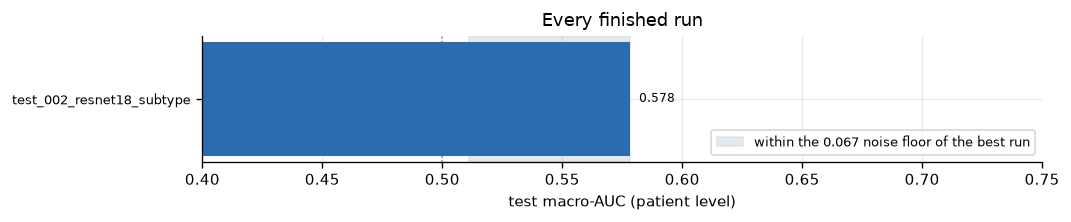

In [5]:
if not runs.empty and runs.test_auc.notna().any():
    plot = runs.dropna(subset=["test_auc"]).sort_values("test_auc")
    labels = plot.apply(lambda r: f"{r['run']}", axis=1)
    best = plot.test_auc.max()

    fig, ax = plt.subplots(figsize=(9, 0.32 * len(plot) + 1.6))
    ax.axvspan(best - NOISE_FLOOR, best, color="#cbd5e0", alpha=0.5,
               label=f"within the {NOISE_FLOOR} noise floor of the best run", zorder=0)
    ax.barh(range(len(plot)), plot.test_auc, color="#2b6cb0", zorder=2)
    ax.set_yticks(range(len(plot)), labels, fontsize=8)
    ax.axvline(0.5, color="grey", ls=":", lw=1, zorder=1)
    ax.set_xlabel("test macro-AUC (patient level)")
    ax.set_xlim(0.4, max(0.75, best + 0.05))
    ax.set_title("Every finished run")
    ax.legend(fontsize=8, loc="lower right")
    for i, v in enumerate(plot.test_auc):
        ax.text(v + 0.004, i, f"{v:.3f}", va="center", fontsize=7)
    plt.tight_layout(); plt.show()
else:
    print("nothing to plot yet")

## The reported federated campaign

The thirteen results the thesis reports do not come from `results/classifier/`.
They live in `results/thesis/`, one folder per test with a summary CSV beside
them, exactly as notebook 07 collected them from the production federation. A
new campaign you collect yourself lands in `results/federated/`.

The table below is the thesis's main result. One centralised run against twelve
federated ones, everything else held identical.

In [6]:
if THESIS_SUMMARY.is_file():
    fed = pd.read_csv(THESIS_SUMMARY)
    cols = [c for c in ["experiment", "kind", "algorithm", "n_clients", "partition",
                        "test_auc", "test_acc", "test_bal", "test_macro_f1"]
            if c in fed]
    print(fed[cols].to_string(index=False))

    central = fed[fed.kind == "centralized"].test_auc.iloc[0]
    federated = fed[fed.kind == "federated"].test_auc
    print(f"\ncentralised           {central:.4f}")
    print(f"federated mean of {len(federated)}  {federated.mean():.4f}")
    print(f"gap                   {central - federated.mean():+.4f}")
    print(f"federated spread      {federated.max() - federated.min():.4f}")
    inside = (abs(federated - central) <= NOISE_FLOOR).sum()
    print(f"\n{inside} of {len(federated)} federated runs sit inside the "
          f"{NOISE_FLOOR} noise floor of the centralised baseline.")
    print("That is the answer to RQ1: the federated system reaches the same place.")
else:
    print(f"{THESIS_SUMMARY} not found — run notebook 07 to collect the campaign")

experiment        kind algorithm  n_clients             partition  test_auc  test_acc  test_bal  test_macro_f1
    test06   federated    fedavg          4    4_clients_balanced    0.6531    0.4776    0.4522         0.4378
    test09   federated   fedprox          4      4_clients_skewed    0.6250    0.4515    0.4210         0.4197
    test07   federated   fedprox          4    4_clients_balanced    0.6075    0.4739    0.4393         0.4362
    test01 centralized         -          1                     -    0.6069    0.5299    0.4503         0.4523
    test04   federated    fedavg          3    3_clients_balanced    0.5990    0.4851    0.4198         0.4231
    test08   federated    fedavg          4      4_clients_skewed    0.5982    0.4888    0.4259         0.4292
    test05   federated   fedprox          3    3_clients_balanced    0.5958    0.4590    0.4127         0.4116
    test03   federated   fedprox          2    2_clients_balanced    0.5917    0.4328    0.4025         0.4001
 

## Comparing two configurations properly

The helper below is what every comparison in the thesis goes through. It reports
the difference and then says whether that difference survives the noise floor.

Nothing else in this project is allowed to declare a winner.

In [7]:
def compare(label_a, value_a, label_b, value_b, noise=NOISE_FLOOR):
    """State a difference and whether it survives the noise floor."""
    delta = value_a - value_b
    verdict = ("no difference detected" if abs(delta) <= noise
               else f"{label_a if delta > 0 else label_b} is ahead")
    print(f"{label_a:<28} {value_a:.4f}")
    print(f"{label_b:<28} {value_b:.4f}")
    print(f"{'difference':<28} {delta:+.4f}   ({verdict}, floor {noise})")
    print()
    return delta


if THESIS_SUMMARY.is_file():
    fed = pd.read_csv(THESIS_SUMMARY).set_index("experiment")
    compare("centralised (test01)", fed.loc["test01", "test_auc"],
            "FedProx skewed (test09)", fed.loc["test09", "test_auc"])
    compare("FedAvg cohort (test10)", fed.loc["test10", "test_auc"],
            "FedProx cohort (test11)", fed.loc["test11", "test_auc"])
    compare("FedAvg cohort (test10)", fed.loc["test10", "test_auc"],
            "FedAvg size-matched (test12)", fed.loc["test12", "test_auc"])
else:
    compare("example A", 0.6068, "example B", 0.5816)

centralised (test01)         0.6069
FedProx skewed (test09)      0.6250
difference                   -0.0181   (no difference detected, floor 0.067)

FedAvg cohort (test10)       0.5426
FedProx cohort (test11)      0.5678
difference                   -0.0252   (no difference detected, floor 0.067)

FedAvg cohort (test10)       0.5426
FedAvg size-matched (test12) 0.5836
difference                   -0.0410   (no difference detected, floor 0.067)



## Export

One CSV with every classifier run, for whatever comes next. It is overwritten each
time, which is fine because it is derived entirely from the run folders.

In [8]:
if not runs.empty:
    OUT_CSV.parent.mkdir(parents=True, exist_ok=True)
    runs.to_csv(OUT_CSV, index=False)
    print(f"written: {OUT_CSV}  ({len(runs)} rows, {len(runs.columns)} columns)")
else:
    print("nothing to export")

written: /Users/daniel/Developer/tese/federated-breast-mri-subtyping/results/classifier/all_experiments.csv  (1 rows, 24 columns)


## What this notebook produced

| path | what it is |
|---|---|
| `results/classifier/all_experiments.csv` | one row per finished local run, every configuration field and every split metric |

Everything else it prints is a view, not a file.

**The one thing to take from it.** The noise floor is 0.067 macro AUC, and most of
the configurations in this project are inside it of each other. That is not a
disappointing result, it is the measurement: on this data and this task, the
ceiling is signal rather than capacity or tuning. It is also why the federated arm
reaching the same band as the centralised baseline is the answer to RQ1 rather than
a near miss.